In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("01-2025.csv")
df1 = pd.read_csv("02-2025.csv")
df2 = pd.read_csv("03-2025.csv")
df3 = pd.read_csv("04-2025.csv")
df4 = pd.read_csv("05-2025.csv")

In [7]:
df = pd.concat([df, df1, df2, df3, df4], ignore_index=True)

In [9]:
df

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,67946352563,2025-01-01 09:01,Outbound,00:00:19,NaN,Sam Steindorf
1,67940463378,2025-01-01 09:01,Outbound,00:00:12,NaN,Sam Steindorf
2,67925186740,2025-01-01 09:02,Inbound,00:18:35,NaN,Sam Steindorf
3,67918009174,2025-01-01 11:00,Outbound,00:03:26,NaN,Sam Steindorf
4,67942371879,2025-01-01 11:03,NaN,00:07:57,NaN,Garrett Evans
...,...,...,...,...,...,...
61560,80537127259,2025-05-31 19:04,Outbound,00:02:01,NaN,David Valdez
61561,80516901171,2025-05-31 20:02,Outbound,00:00:04,NaN,David Valdez
61562,80525970774,2025-05-31 20:06,Outbound,00:00:04,NaN,David Valdez
61563,80531941560,2025-05-31 21:51,Inbound,00:00:00,NaN,NaN


In [11]:
df1 = df.drop(columns=['hs_call_outcome', 'Record ID'])

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 61565 entries, 0 to 61564
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         61565 non-null  str  
 1   Call direction        56995 non-null  str  
 2   Call duration         57671 non-null  str  
 3   Activity assigned to  58745 non-null  str  
dtypes: str(4)
memory usage: 4.4 MB


In [15]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# Call Count per Day

In [18]:
df2 = df1.copy()

In [20]:
df2['date'] = df2['Activity date'].dt.date

In [22]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-01-01 09:01:00,Outbound,00:00:19,Sam Steindorf,2025-01-01
1,2025-01-01 09:01:00,Outbound,00:00:12,Sam Steindorf,2025-01-01
2,2025-01-01 09:02:00,Inbound,00:18:35,Sam Steindorf,2025-01-01
3,2025-01-01 11:00:00,Outbound,00:03:26,Sam Steindorf,2025-01-01
4,2025-01-01 11:03:00,NaN,00:07:57,Garrett Evans,2025-01-01


In [24]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

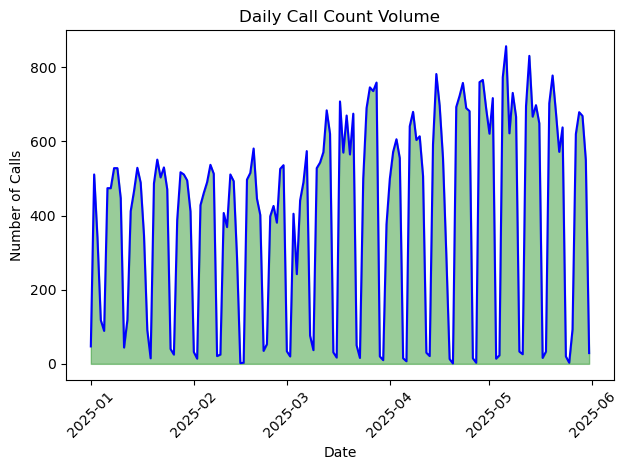

In [26]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color= 'blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color = 'green', alpha=0.4)

plt.title("Daily Call Count Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to
0,2025-01-01 09:01:00,Outbound,00:00:19,Sam Steindorf
1,2025-01-01 09:01:00,Outbound,00:00:12,Sam Steindorf
2,2025-01-01 09:02:00,Inbound,00:18:35,Sam Steindorf
3,2025-01-01 11:00:00,Outbound,00:03:26,Sam Steindorf
4,2025-01-01 11:03:00,NaN,00:07:57,Garrett Evans


# Count of Call in Weekdays

In [31]:
df1['day'] = df1['Activity date'].dt.day_name()

In [33]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-01-01 09:01:00,Outbound,00:00:19,Sam Steindorf,Wednesday
1,2025-01-01 09:01:00,Outbound,00:00:12,Sam Steindorf,Wednesday
2,2025-01-01 09:02:00,Inbound,00:18:35,Sam Steindorf,Wednesday
3,2025-01-01 11:00:00,Outbound,00:03:26,Sam Steindorf,Wednesday
4,2025-01-01 11:03:00,NaN,00:07:57,Garrett Evans,Wednesday


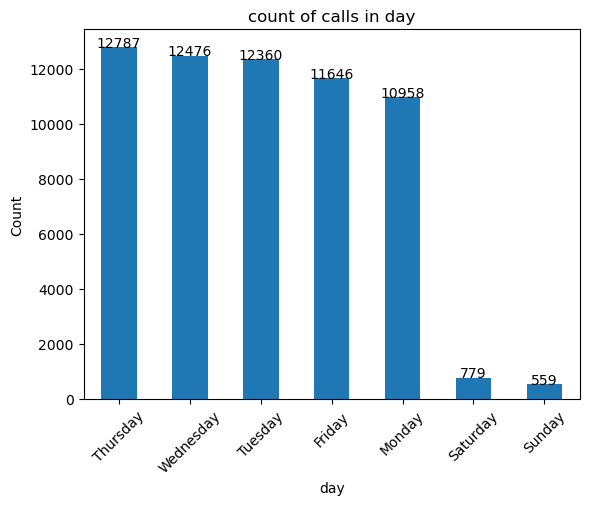

In [35]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i,v+1, str(v), ha= "center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

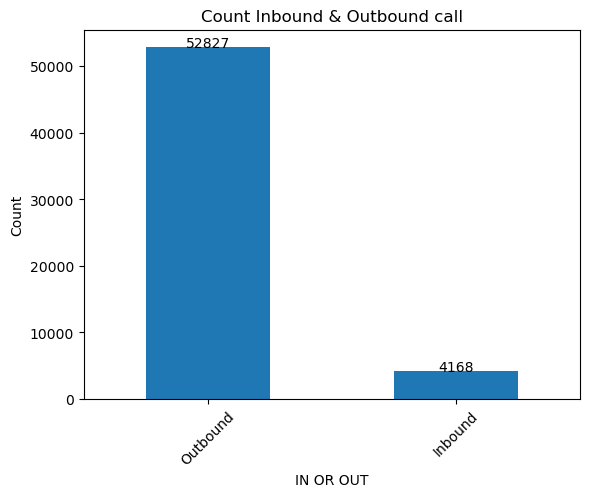

In [38]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [41]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

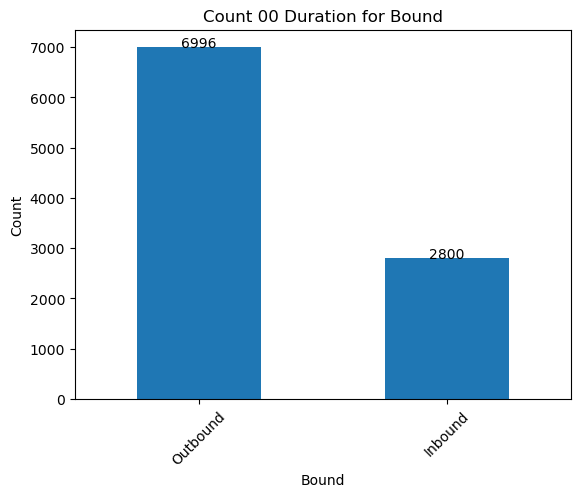

In [43]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call Duration NULL but have Call direction

In [46]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
2198,2025-01-08 14:00:00,Outbound,NaN,Chrystel Manabat,Wednesday
4808,2025-01-15 15:36:00,Outbound,NaN,Keith Antonio,Wednesday
5619,2025-01-17 09:25:00,Inbound,NaN,Robin Stoehr,Friday
6597,2025-01-21 11:00:00,Outbound,NaN,Chrystel Manabat,Tuesday
6665,2025-01-21 12:18:00,Outbound,NaN,Keith Antonio,Tuesday
...,...,...,...,...,...
52808,2025-05-13 12:43:00,Outbound,NaN,Keith Antonio,Tuesday
52815,2025-05-13 12:48:00,Outbound,NaN,Jerome Joyce,Tuesday
52914,2025-05-13 14:02:00,Outbound,NaN,Robin Stoehr,Tuesday
53470,2025-05-14 09:29:00,Inbound,NaN,Robin Stoehr,Wednesday


In [48]:
df4 = df1.copy()

In [50]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-01-01 09:01:00,Outbound,00:00:19,Sam Steindorf,Wednesday
1,2025-01-01 09:01:00,Outbound,00:00:12,Sam Steindorf,Wednesday
2,2025-01-01 09:02:00,Inbound,00:18:35,Sam Steindorf,Wednesday
3,2025-01-01 11:00:00,Outbound,00:03:26,Sam Steindorf,Wednesday
4,2025-01-01 11:03:00,NaN,00:07:57,Garrett Evans,Wednesday


In [52]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [54]:
(df4['Call duration'] == 0).sum()

9796

In [56]:
df4['Call duration'].isnull().sum()

3894

In [58]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 61565 entries, 0 to 61564
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         61565 non-null  datetime64[us]
 1   Call direction        56995 non-null  str           
 2   Call duration         57671 non-null  float64       
 3   Activity assigned to  58745 non-null  str           
 4   day                   61565 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 3.9 MB


In [60]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [62]:
df4 = df4.dropna(subset = ['Call direction'])

In [64]:
df4['Call duration'].isnull().sum()

0

In [66]:
df4['Call direction'].isnull().sum()

0

In [68]:
(df4['Call duration'] == 0).sum()

10012

In [70]:
df4.info()

<class 'pandas.DataFrame'>
Index: 56995 entries, 0 to 61564
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         56995 non-null  datetime64[us]
 1   Call direction        56995 non-null  str           
 2   Call duration         56995 non-null  float64       
 3   Activity assigned to  54232 non-null  str           
 4   day                   56995 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 4.1 MB


# Working Call Assigner

In [73]:
df1['Activity assigned to'].nunique()

34

In [75]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[    'Sam Steindorf',     'Garrett Evans',   'Spenser Szakacs',
                 nan,     'Oliver Martin',       'Tyler Smith',
    'Boston Hoppman',      'David Valdez',      'Robin Stoehr',
     'Keith Antonio',    'Cameron Dudley',       'Paol Guzman',
         'Terry Kim',        'Tyler Jury',    'David Banister',
      'Karen Parker', 'Brittany Digiulio',         'Juan Calo',
  'Chrystel Manabat',   'Adonis Baybayan',    'Nick Rothacher',
      'Bill Goodwin',   'Christian Banks',   'Blake Roudebush',
       'Kevin Nuesi',          'June Kim',       'Jon Karimov',
            'Abhi C',    'Stephen Legath',      'Cameron Byrd',
       'Jinky Rance',      'Jerome Joyce',     'Hugo Almendra',
      'Stephen Tarr',  'Vladimir Suparto']
Length: 35, dtype: str

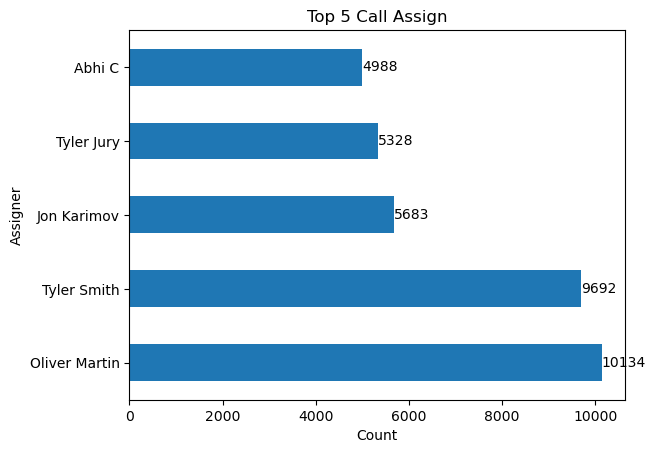

In [77]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# MAX CALL DURATION

In [80]:
df4['Call duration'].max()

146.18333333333334

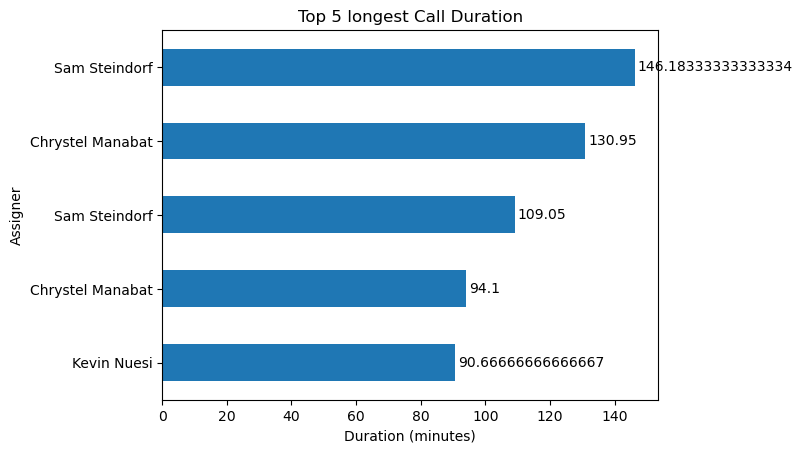

In [82]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Week days Call Volume

In [85]:
df3=df1.copy()

In [87]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [89]:
df3['day'].unique()

<ArrowStringArray>
['Wednesday', 'Thursday', 'Friday', 'Monday', 'Tuesday']
Length: 5, dtype: str

In [91]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

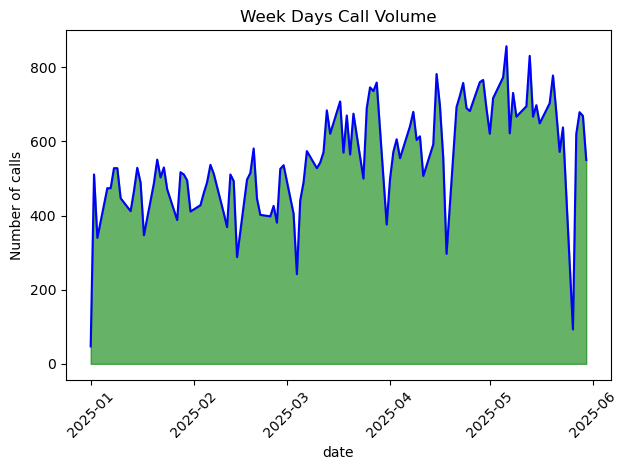

In [93]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [96]:
df5 = df4.copy()

In [98]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [100]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
898,2025-01-04 03:28:00,Inbound,0.000000,NaN,Saturday
900,2025-01-04 10:10:00,Outbound,0.116667,David Valdez,Saturday
901,2025-01-04 10:11:00,Outbound,0.066667,David Valdez,Saturday
902,2025-01-04 10:24:00,Outbound,0.033333,David Valdez,Saturday
903,2025-01-04 11:01:00,Outbound,7.066667,Sam Steindorf,Saturday


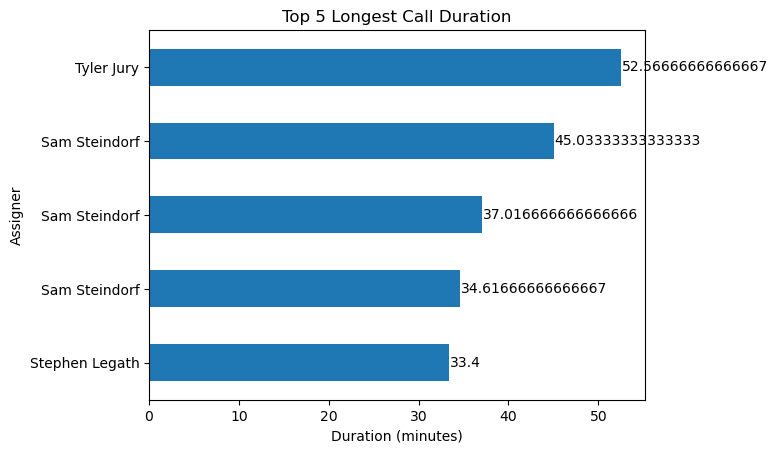

In [102]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

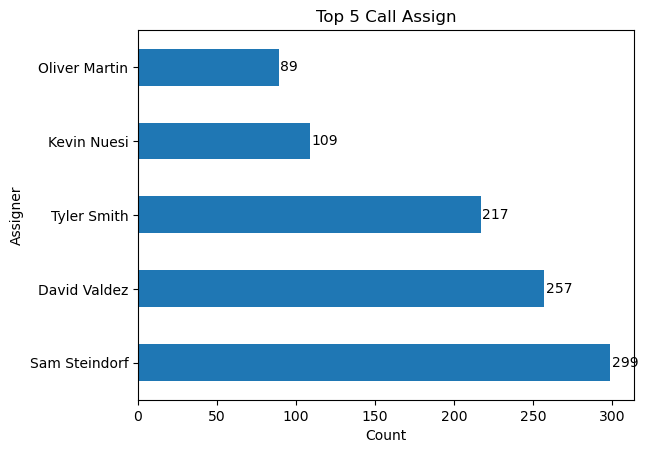

In [105]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Monthly Call Count

In [108]:
df6 = df3.copy()

In [110]:
df6['month'] = df6['Activity date'].dt.month_name()

In [112]:
df6.head()

,Activity date,Call direction,Call duration,Activity assigned to,day,month
0,2025-01-01 09:01:00,Outbound,00:00:19,Sam Steindorf,Wednesday,January
1,2025-01-01 09:01:00,Outbound,00:00:12,Sam Steindorf,Wednesday,January
2,2025-01-01 09:02:00,Inbound,00:18:35,Sam Steindorf,Wednesday,January
3,2025-01-01 11:00:00,Outbound,00:03:26,Sam Steindorf,Wednesday,January
4,2025-01-01 11:03:00,NaN,00:07:57,Garrett Evans,Wednesday,January


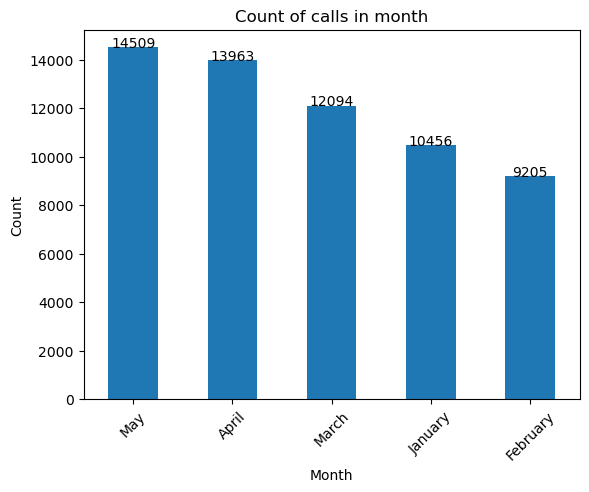

In [114]:
month_counts = df6["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls in month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Average Call Duration

In [117]:
df4["Call duration"].mean()

1.8572322133520485

In [119]:
df4["Call duration"].median()

0.1

# WITHOUT CALL ASSIGNER CALLS

In [122]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

In [124]:
no_assigner_calls.info()

<class 'pandas.DataFrame'>
Index: 2686 entries, 6 to 61535
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         2686 non-null   datetime64[us]
 1   Call direction        2629 non-null   str           
 2   Call duration         2685 non-null   str           
 3   Activity assigned to  0 non-null      str           
 4   day                   2686 non-null   str           
 5   month                 2686 non-null   str           
dtypes: datetime64[us](1), str(5)
memory usage: 219.9 KB


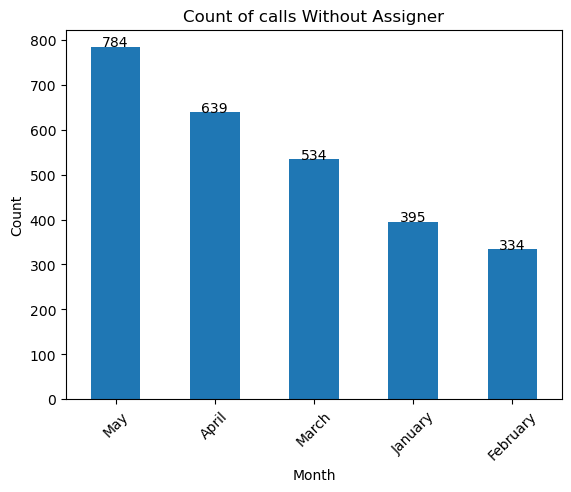

In [126]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 PEAK CALL DATE

In [129]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [131]:
top5 = daily_calls.sort_values(ascending=False).head(5)

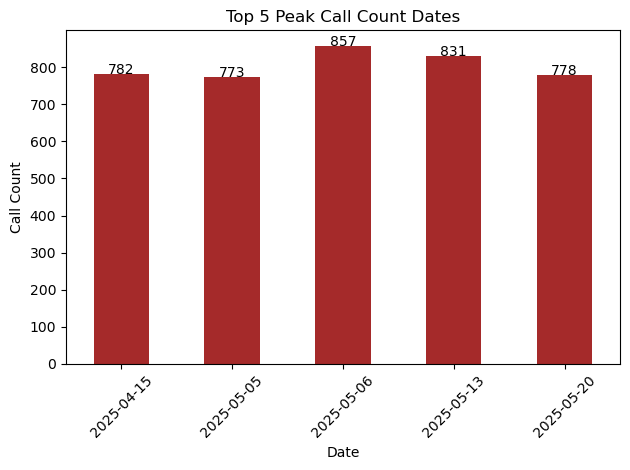

In [133]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count Dates")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()